In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
hormones = pd.read_csv('/content/drive/MyDrive/ML csv files/hormones_and_selfreport.csv')

In [ ]:
hormones.head()

,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,...,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,Not at all,...,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


In [ ]:
hormones.shape

(5659, 22)

In [ ]:
key = ['id', 'study_interval', 'day_in_study']

hormones = hormones[key + ['phase'] + ['stress']]

In [ ]:
print(hormones.isna().sum())

id                   0
study_interval       0
day_in_study         0
phase                1
stress            2332
dtype: int64


In [ ]:
hormones = hormones.dropna(subset=['phase'])

hormones = hormones[hormones['stress'].notna()].copy()
print("Rows remaining:", len(hormones))

Rows remaining: 3326


In [ ]:
print(hormones.isna().sum())

id                0
study_interval    0
day_in_study      0
phase             0
stress            0
dtype: int64


In [ ]:
print("Total rows:", len(hormones))
print("Rows missing stress:", hormones['stress'].isna().sum())
print("\nStress distribution:")
print(hormones['stress'].value_counts(dropna=False))

Total rows: 3326
Rows missing stress: 0

Stress distribution:
stress
Moderate           1047
High                610
Low                 567
Not at all          436
Very Low/Little     369
Very High           290
2                     4
3                     2
1                     1
Name: count, dtype: int64


In [ ]:
valid_labels = ['Moderate', 'High', 'Low', 'Not at all', 'Very Low/Little', 'Very High']
before = len(hormones)
hormones = hormones[hormones['stress'].isin(valid_labels)]

stress
Moderate           0.315
High               0.184
Low                0.171
Not at all         0.131
Very Low/Little    0.111
Very High          0.087
Name: proportion, dtype: float64

Imbalance ratio: 3.6


<Axes: xlabel='stress'>

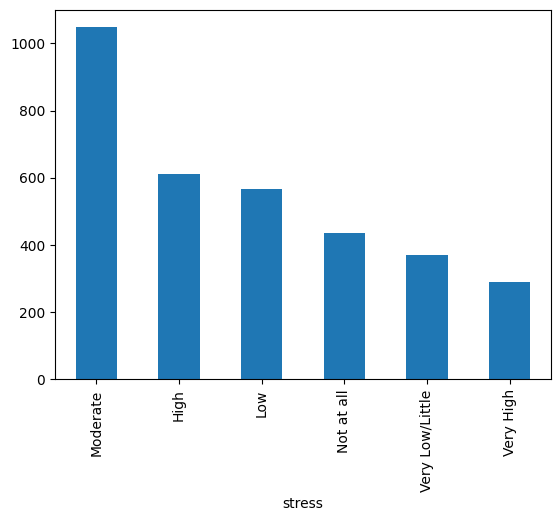

In [ ]:
print(hormones['stress'].value_counts(normalize=True).round(3))

counts = hormones['stress'].value_counts()
print("\nImbalance ratio:", round(counts.max() / counts.min(), 1))

hormones['stress'].value_counts().plot(kind='bar')

In [ ]:
# collapsing to 3 classes
stress_map = {
    'Not at all': 'Low', 'Very Low/Little': 'Low', 'Low': 'Low',
    'Moderate': 'Moderate',
    'High': 'High', 'Very High': 'High',
}
hormones['stress'] = hormones['stress'].map(stress_map)
print(hormones['stress'].value_counts())


stress
Low         1372
Moderate    1047
High         900
Name: count, dtype: int64


In [ ]:
# encoding
encode_map = {'Low': 0, 'Moderate': 1, 'High': 2}
hormones['stress'] = hormones['stress'].map(encode_map)
print(hormones['stress'].value_counts())

# check the class imbalance now
counts = hormones['stress'].value_counts()
print("New imbalance ratio:", round(counts.max() / counts.min(), 1))

stress
0    1372
1    1047
2     900
Name: count, dtype: int64
New imbalance ratio: 1.5


Decision Tree

In [ ]:
phase_dummies = pd.get_dummies(hormones['phase'], prefix='phase')
hormones = pd.concat([hormones, phase_dummies], axis=1)

feature_cols_phase = list(phase_dummies.columns)
print(feature_cols_phase)

['phase_Fertility', 'phase_Follicular', 'phase_Luteal', 'phase_Menstrual']


In [ ]:
hormones

,id,study_interval,day_in_study,phase,stress,phase_Fertility,phase_Follicular,phase_Luteal,phase_Menstrual
0,1,2022,1,Follicular,1,False,True,False,False
1,1,2022,2,Follicular,1,False,True,False,False
2,1,2022,3,Follicular,0,False,True,False,False
3,1,2022,4,Fertility,0,True,False,False,False
4,1,2022,5,Fertility,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...
5550,50,2022,85,Luteal,2,False,False,True,False
5551,50,2022,86,Luteal,1,False,False,True,False
5552,50,2022,87,Luteal,1,False,False,True,False
5553,50,2022,88,Menstrual,1,False,False,False,True


In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold

X_phase      = pd.get_dummies(hormones['phase'], prefix='phase')
y_phase      = hormones['stress']
groups_phase = hormones['id']
sgkf         = StratifiedGroupKFold(n_splits=5)

rows = []
for depth in [1, 2, 3, 4, 5]:
    model = DecisionTreeClassifier(max_depth=depth,
                                   class_weight='balanced',
                                   random_state=42)
    scores = cross_val_score(model, X_phase, y_phase, groups=groups_phase,
                             cv=sgkf, scoring='f1_macro', n_jobs=-1)
    rows.append({'depth': depth, 'macro_f1': scores.mean(), 'std': scores.std()})

print()
print(pd.DataFrame(rows).round(3).to_string(index=False))


 depth  macro_f1   std
     1     0.250 0.019
     2     0.304 0.041
     3     0.302 0.039
     4     0.302 0.039
     5     0.302 0.039


In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

rows = []
for depth in [1, 2, 3, 4, 5]:
    for leaf in [1, 5, 10, 20, 50]:
        model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf,
                                       class_weight='balanced', random_state=42)
        scores = cross_val_score(model, X_phase, y_phase, groups=groups_phase,
                                 cv=sgkf, scoring='f1_macro', n_jobs=-1)
        rows.append({'depth': depth, 'leaf': leaf, 'macro_f1': scores.mean()})

grid = pd.DataFrame(rows).pivot(index='depth', columns='leaf', values='macro_f1')
print(grid.round(3))

leaf      1      5      10     20     50
depth                                   
1      0.250  0.250  0.250  0.250  0.250
2      0.304  0.304  0.304  0.304  0.304
3      0.302  0.302  0.302  0.302  0.302
4      0.302  0.302  0.302  0.302  0.302
5      0.302  0.302  0.302  0.302  0.302


              precision    recall  f1-score   support

         Low       0.40      0.34      0.37      1372
    Moderate       0.31      0.27      0.29      1047
        High       0.28      0.39      0.32       900

    accuracy                           0.33      3319
   macro avg       0.33      0.33      0.33      3319
weighted avg       0.34      0.33      0.33      3319



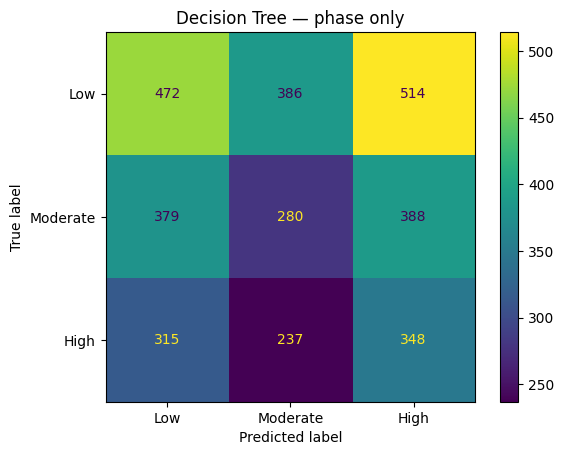

|--- phase_Luteal <= 0.50
|   |--- phase_Follicular <= 0.50
|   |   |--- class: High
|   |--- phase_Follicular >  0.50
|   |   |--- class: Moderate
|--- phase_Luteal >  0.50
|   |--- class: Low



In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

dt_phase = DecisionTreeClassifier(max_depth=2, min_samples_leaf=5,
                                  class_weight='balanced', random_state=42)

preds_phase = cross_val_predict(dt_phase, X_phase, y_phase,
                                groups=groups_phase, cv=sgkf)

print(classification_report(y_phase, preds_phase,
                            target_names=['Low','Moderate','High']))

ConfusionMatrixDisplay.from_predictions(y_phase, preds_phase,
                                        display_labels=['Low','Moderate','High'])
plt.title('Decision Tree — phase only')
plt.show()

dt_phase.fit(X_phase, y_phase)
print(export_text(dt_phase, feature_names=list(X_phase.columns),
                  class_names=['Low','Moderate','High']))

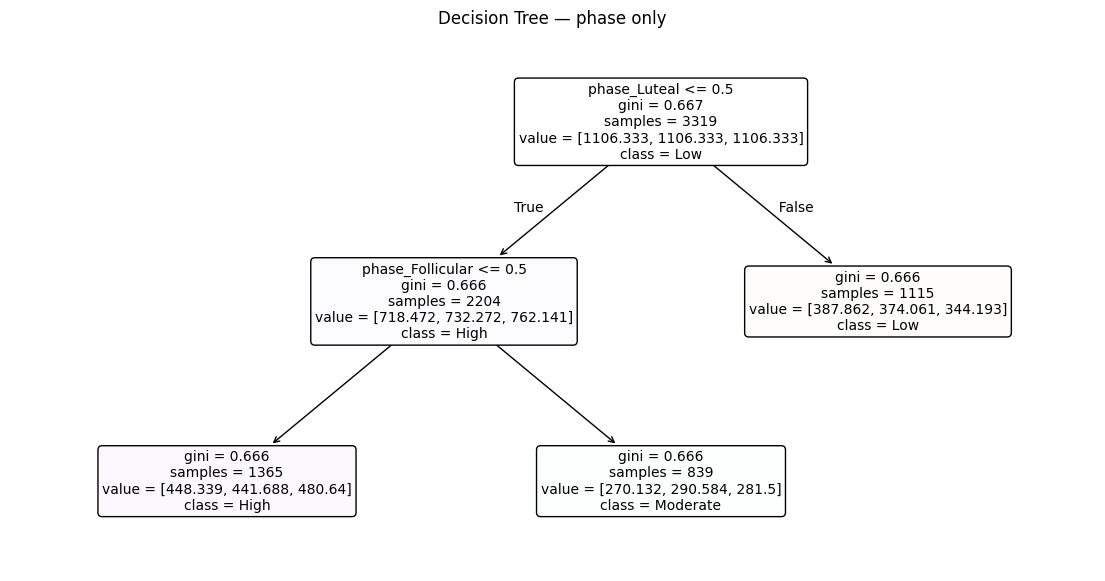

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 7))
plot_tree(dt_phase, feature_names=list(X_phase.columns),
          class_names=['Low','Moderate','High'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree — phase only')
plt.show()